In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVE_FIGURES = True 

MAX_STEP = 285_000

def ema(x, alpha=0.05):
    out = np.zeros_like(x)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1-alpha) * out[i-1]
    return out

In [2]:
# causal + sinh^(-1)
df = pd.read_csv('traininglosses/causalsinh_small.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_causalsinh = df["causalsinh_small - train_loss"].values

In [3]:
# causal
df = pd.read_csv('traininglosses/causal_small.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_causal = df["causal_small - train_loss"].values

In [4]:
# vanilla
df = pd.read_csv('traininglosses/vanilla_small.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_vanilla = df["vanilla_small - train_loss"].values

In [5]:
# vanilla + sinh^(-1)
df = pd.read_csv('traininglosses/vanillasinh_small.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_vanillasinh = df["vanillasinh_small - train_loss"].values

In [6]:
# prefix@8
df = pd.read_csv('traininglosses/prefix8_small.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_prefix8 = df["prefix8_small - train_loss"].values

In [7]:
# prefix@8 + sinh^(-1)
df = pd.read_csv('traininglosses/prefix8sinh_small.csv')
df = df[df["trainer/global_step"]<=MAX_STEP]
train_loss_prefix8sinh = df["prefix8sinh_small - train_loss"].values

In [8]:
dic_model_colors = {
    "Causal RevIN":          "#FF7F00",  # vivid orange
    "Causal RevIN + asinh":  "#573030FF",  # semi-transparent brown
    "RevIN":                 "#00CC66",  # vivid green
    "RevIN + asinh":         "#0055FF",  # electric deep blue
    "Prefix@8 RevIN":              "#FF3300",  # bright red-orange
    "Prefix@8 RevIN + asinh":      "#CC0099",  # strong magenta
}

dic_model_symbols = {
    "Causal RevIN":          "o",   # circle
    "Causal RevIN + asinh":  "x",   # cross
    "RevIN":                 "s",   # square
    "RevIN + asinh":         "d",   # diamond
    "Prefix@8 RevIN":              "^",   # triangle up
    "Prefix@8 RevIN + asinh":      "v",   # triangle down
}

In [9]:
x = np.linspace(0, MAX_STEP, len(train_loss_causal))

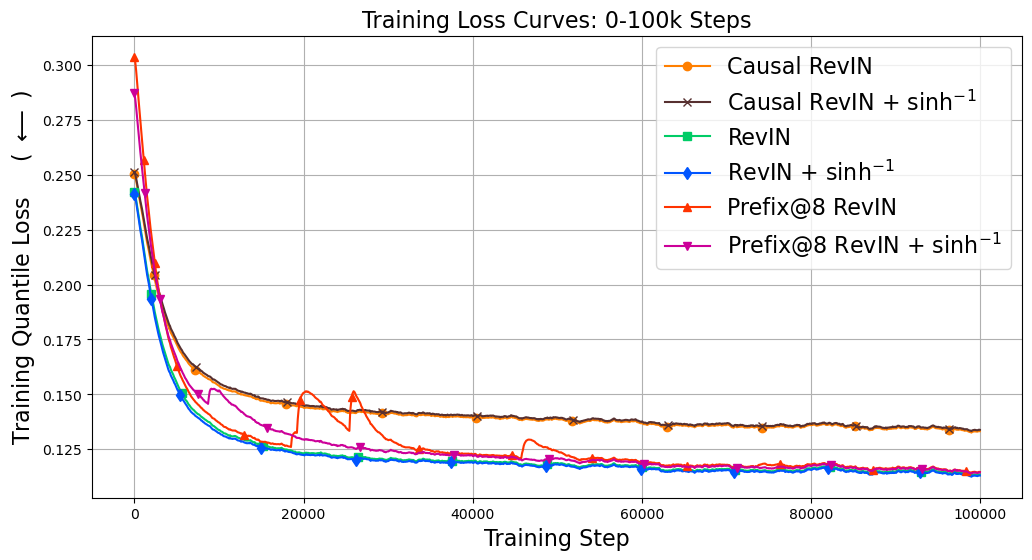

In [10]:
START, END = 0, 100_000
start_index = int(START / 285_000 * len(train_loss_causal))
end_index = int(END / 285_000 * len(train_loss_causal))



plt.figure(figsize=(12, 6))

plt.plot(x[start_index:end_index], ema(train_loss_causal)[start_index:end_index], label="Causal RevIN", color=dic_model_colors["Causal RevIN"], marker=dic_model_symbols["Causal RevIN"], markevery=0.1)
plt.plot(x[start_index:end_index], ema(train_loss_causalsinh)[start_index:end_index], label="Causal RevIN + $\sinh^{-1}$", color=dic_model_colors["Causal RevIN + asinh"], marker=dic_model_symbols["Causal RevIN + asinh"], markevery=0.1)
plt.plot(x[start_index:end_index], ema(train_loss_vanillasinh)[start_index:end_index], label="RevIN", color=dic_model_colors["RevIN"], marker=dic_model_symbols["RevIN"], markevery=0.1)
plt.plot(x[start_index:end_index], ema(train_loss_vanilla)[start_index:end_index], label="RevIN + $\sinh^{-1}$", color=dic_model_colors["RevIN + asinh"], marker=dic_model_symbols["RevIN + asinh"], markevery=0.1)
plt.plot(x[start_index:end_index], ema(train_loss_prefix8)[start_index:end_index], label="Prefix@8 RevIN", color=dic_model_colors["Prefix@8 RevIN"], marker=dic_model_symbols["Prefix@8 RevIN"], markevery=0.1)
plt.plot(x[start_index:end_index], ema(train_loss_prefix8sinh)[start_index:end_index], label="Prefix@8 RevIN + $\sinh^{-1}$", color=dic_model_colors["Prefix@8 RevIN + asinh"], marker=dic_model_symbols["Prefix@8 RevIN + asinh"], markevery=0.1)  

plt.xlabel("Training Step", fontsize=16)
plt.ylabel("Training Quantile Loss     ( $\longleftarrow$ )", fontsize=16)
plt.title("Training Loss Curves: 0-100k Steps", fontsize=16)
plt.legend(fontsize=16)
plt.grid()

if SAVE_FIGURES:
    plt.savefig("figures/training_loss_curves_0_100k_small.pdf", dpi=300, bbox_inches='tight')
plt.show()

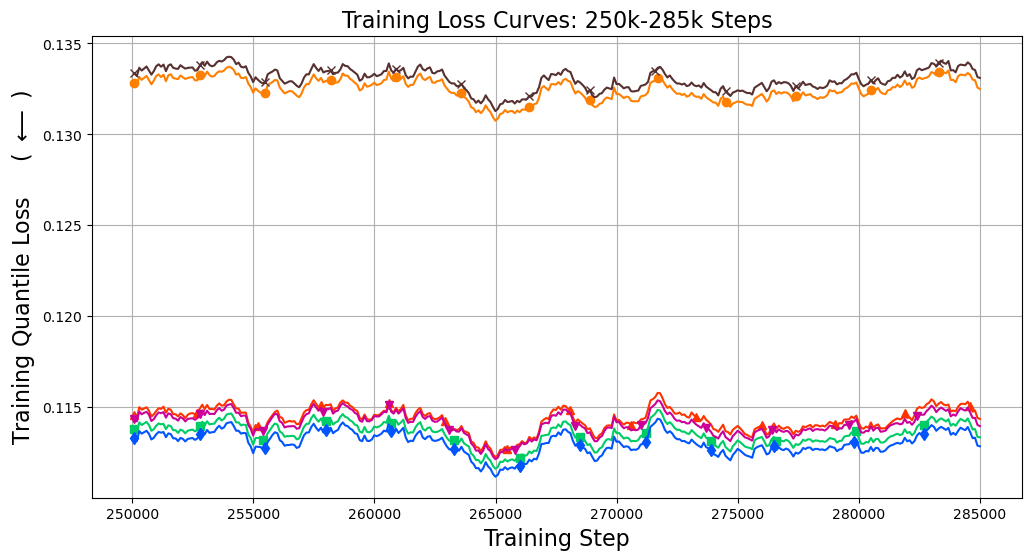

In [11]:
START, END = 250_000, 285_000
start_index = int(START / 285_000 * len(train_loss_causal))
end_index = int(END / 285_000 * len(train_loss_causal))


plt.figure(figsize=(12, 6))

plt.plot(x[start_index:end_index], ema(train_loss_causal)[start_index:end_index], label="Causal RevIN", color=dic_model_colors["Causal RevIN"], marker=dic_model_symbols["Causal RevIN"], markevery=0.1)
plt.plot(x[start_index:end_index], ema(train_loss_causalsinh)[start_index:end_index], label="Causal RevIN + $\sinh^{-1}$", color=dic_model_colors["Causal RevIN + asinh"], marker=dic_model_symbols["Causal RevIN + asinh"], markevery=0.1)
plt.plot(x[start_index:end_index], ema(train_loss_vanillasinh)[start_index:end_index], label="RevIN", color=dic_model_colors["RevIN"], marker=dic_model_symbols["RevIN"], markevery=0.1)
plt.plot(x[start_index:end_index], ema(train_loss_vanilla)[start_index:end_index], label="RevIN + $\sinh^{-1}$", color=dic_model_colors["RevIN + asinh"], marker=dic_model_symbols["RevIN + asinh"], markevery=0.1)
plt.plot(x[start_index:end_index], ema(train_loss_prefix8)[start_index:end_index], label="Prefix@8 RevIN", color=dic_model_colors["Prefix@8 RevIN"], marker=dic_model_symbols["Prefix@8 RevIN"], markevery=0.1)
plt.plot(x[start_index:end_index], ema(train_loss_prefix8sinh)[start_index:end_index], label="Prefix@8 RevIN + $\sinh^{-1}$", color=dic_model_colors["Prefix@8 RevIN + asinh"], marker=dic_model_symbols["Prefix@8 RevIN + asinh"], markevery=0.1)  

plt.xlabel("Training Step", fontsize=16)
plt.ylabel("Training Quantile Loss     ( $\longleftarrow$ )", fontsize=16)
plt.title("Training Loss Curves: 250k-285k Steps", fontsize=16)

#plt.legend()
plt.grid()
if SAVE_FIGURES:
    plt.savefig("figures/training_loss_curves_250k_285k_small.pdf", dpi=300, bbox_inches='tight')
plt.show()